In [5]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

In [6]:
tarball_path = Path("datasets/housing.tgz")
if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
    tarfile.open(tarball_path).extractall(path="datasets", filter="data")

housing_full = pd.read_csv("datasets/housing/housing.csv")

In [7]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
housing_full['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
housing_full['ocean_proximity'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: ocean_proximity
Non-Null Count  Dtype 
--------------  ----- 
20640 non-null  object
dtypes: object(1)
memory usage: 161.4+ KB


In [12]:

housing_full['ocean_proximity'].describe()

count         20640
unique            5
top       <1H OCEAN
freq           9136
Name: ocean_proximity, dtype: object

In [13]:
housing_full['ocean_proximity'].head()

0    NEAR BAY
1    NEAR BAY
2    NEAR BAY
3    NEAR BAY
4    NEAR BAY
Name: ocean_proximity, dtype: object

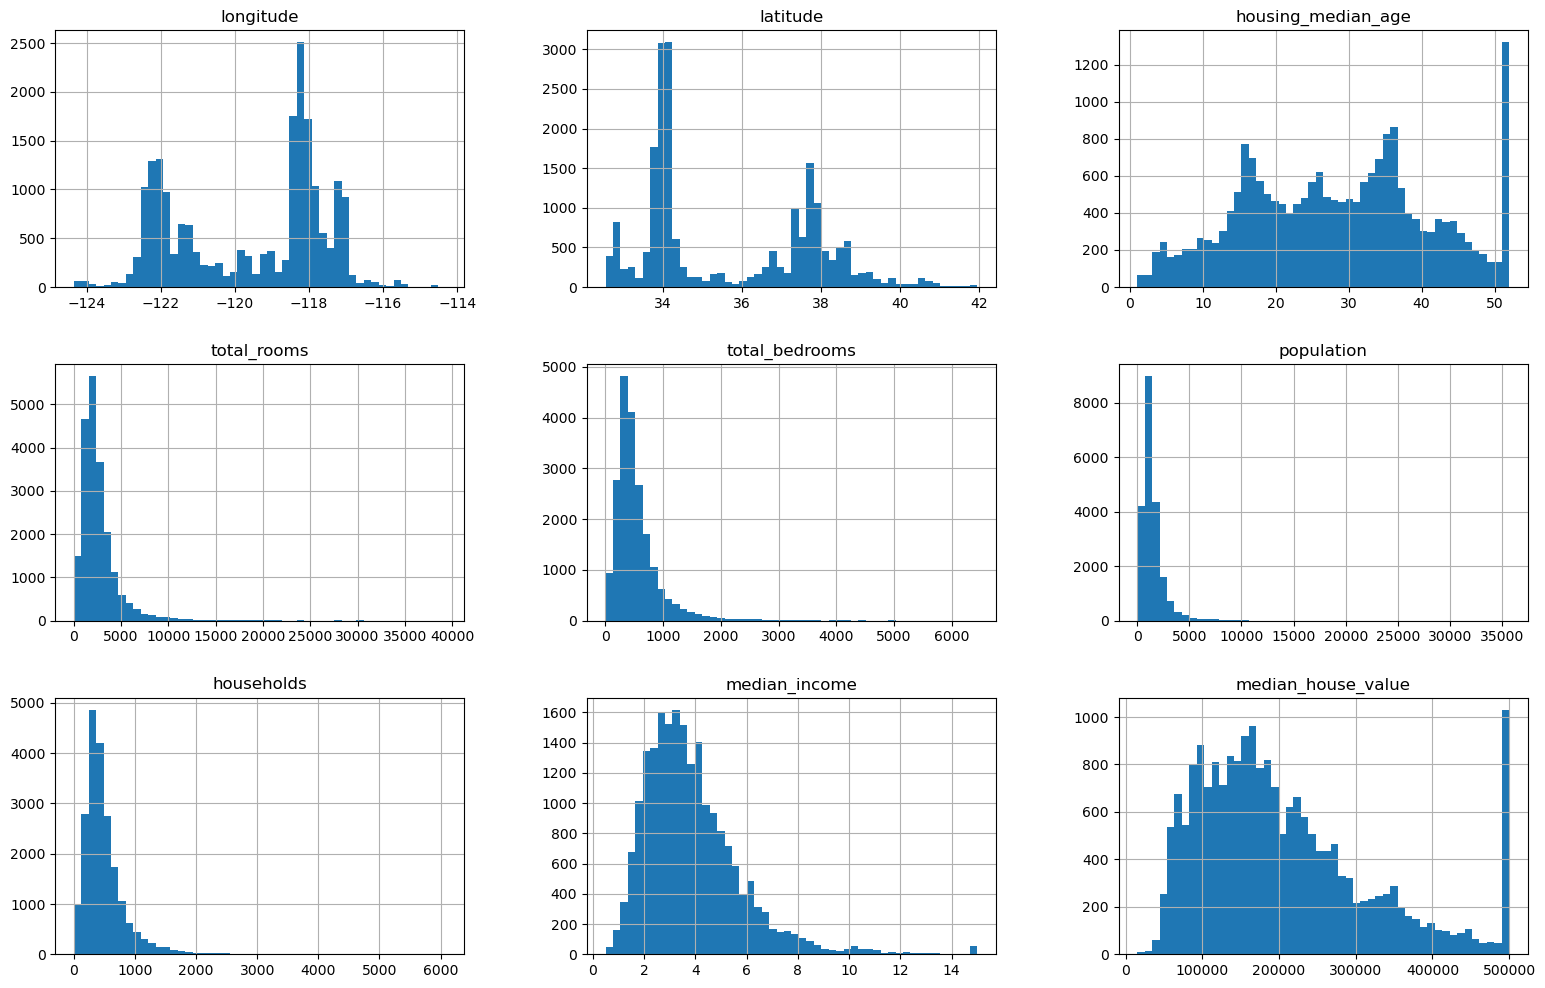

In [14]:
import matplotlib.pyplot as plt

housing_full.hist(bins=50, figsize=(19,12) )
plt.show()

In [15]:
import numpy as np

def shuffle_and_split_train_test_data(data,ratio):
    rng = np.random.default_rng()
    shuffled_data = rng.permutation(len(data))
    test_len = int(len(data) * ratio)
    test_data_indices = shuffled_data[:test_len]
    train_data_indices = shuffled_data[test_len:]

    return data.iloc[train_data_indices], data.iloc[test_data_indices]

train_set, test_set = shuffle_and_split_train_test_data(housing_full,0.2)

In [16]:
print(len(train_set), len(test_set))

16512 4128


this is not good, if we run the program again it will output different test and train set, which we should avoid because we dont want out ML model to see the test set

**Alternatives**-
1. save the test set on first run and use it later
2. give a seed to default_rng() like np.random.default_rng(42), a fixed seed keeps the fixed random no. as output every time we run the program

Both these solutions will break the next time you fetch an updated dataset

**Solutions for stable train/test split even after updating the dataset**


In [17]:
from zlib import crc32

def id_goes_in_test_set(id, test_ratio):
    return crc32(np.int64(id)) < (test_ratio * 2**32)

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id: id_goes_in_test_set(id, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set] #dataframe.iloc[`boolean_series`.to_numpy()] will work as well


housing_full_with_id =  housing_full.reset_index() #adds an 'index' column to the dataframe
train_set, test_set = split_data_with_id_hash(housing_full_with_id, 0.2, "index")

we are taking the ids hashing it with `crc32` algo which ranges from `0 to 2^32` and then we are checking if the hashed value is less than 20% of the full range of 0 to 2^32, we are only putting the first 20% of data in test set


Q. what if no hashed indentifier goes in testdata? is that possible?

Ans. Yes, theoretically possible, but the probability is very low,
- `crc32` distributes the values very evenly
- so, probability that none falls in 20% region/range is:
  - `(0.8)^n` where n is the number of samples, and 0.8 is the 80% region left out where each sample falls in. 
  - for 100 samples, the probability is `(0.8)^1000` which is around `0.0000000002`
  - for 1000 samples, the probability is `(0.8)^10000` which is around `0`

##### <u>So what happens when when new data gets added to the dataset?</u>

**The rule is**: “Put a row in test set if its hash falls in the lowest 20% range.”

That rule never changes.  
It does NOT mean: “Pick exactly 20% of the dataset”  

It means: “Each row independently has a 20% chance of being in test set”  

**What changes when new data is added?**

Let’s say:

Initially: 100 rows → ~20 go to test set  
Now you add 50 new rows:  
Each new row again has 20% chance → ~10 new test rows  
So now:  
Total rows = 150 and Test rows ≈ 30  

In [18]:
housing_full_with_id["id"] = (housing_full["longitude"] * 1000
+ housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_full_with_id, 0.2, "id")

In [19]:
from sklearn.model_selection import train_test_split

#train_test_split works same as our implemented function shuffle_and_split_train_test_data
random_train_set, random_test_set = train_test_split(housing_full, test_size=0.2, random_state=42) #random_state sets the random generator seed

this will create sampling bias, since we are not representing the data properly, `train_set` should be such that it represents the whole dataset

We need **Stratified sampling**: the population is divided into homogeneous subgroups (called strata), and right no. of instances are sampled from each stratum

In our case, we got to know that `median_income` is the most important attribute to predict the `median_house_value`, so we will create strata based on `median_income` and then do random sampling in each stratum

It is important to have a sufficient number of instances in your dataset for each stratum,
or else the estimate of a stratum’s importance may be biased. This means that you
should not have too many strata, and each stratum should be large enough.

Text(0, 0.5, 'no. of districts')

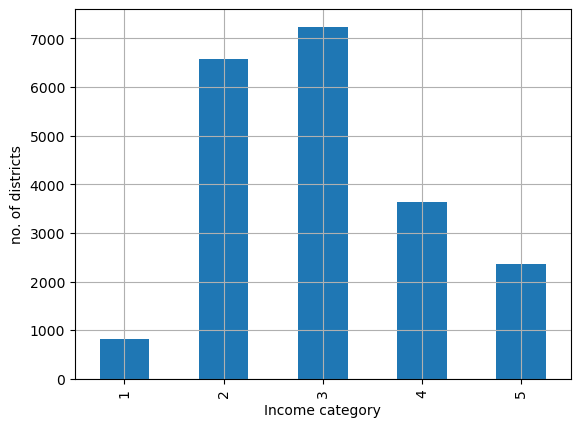

In [20]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],labels=[1, 2, 3, 4, 5])

housing_full['income_cat'].value_counts().sort_index().plot(kind='bar', grid=True)
plt.xlabel('Income category')
plt.ylabel("no. of districts")

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []

for train_index, test_index in splitter.split(housing_full, housing_full['income_cat']):
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n  =  housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

strat_train_set, strat_test_set = strat_splits[0]
strat_train_set, strat_test_set 

(       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
 13096    -122.42     37.80                52.0       3321.0          1115.0   
 14973    -118.38     34.14                40.0       1965.0           354.0   
 3785     -121.98     38.36                33.0       1083.0           217.0   
 14689    -117.11     33.75                17.0       4174.0           851.0   
 20507    -118.15     33.77                36.0       4366.0          1211.0   
 ...          ...       ...                 ...          ...             ...   
 14207    -118.40     33.86                41.0       2237.0           597.0   
 13105    -119.31     36.32                23.0       2945.0           592.0   
 19301    -117.06     32.59                13.0       3920.0           775.0   
 19121    -118.40     34.06                37.0       3781.0           873.0   
 19888    -122.41     37.66                44.0        431.0           195.0   
 
        population  households  median

In [22]:
#shorter way 
strat_train_set, strat_test_set = train_test_split(housing_full, test_size=0.2, random_state=42, stratify=housing_full['income_cat'])

In [23]:
#to check the distribution in each category of income with "Startified" way, "Orginal"(as it is) way and "Random"(using train_test_split()) way
# OR, Sampling bias comparison of stratified vs purely random sampling

strat = strat_test_set['income_cat'].value_counts(normalize=True).sort_index() #normalize=True gives the proportion instead of count
overall = housing_full['income_cat'].value_counts(normalize=True).sort_index()
strat_err = ((strat / overall) * 100).round(2).sort_index()


random_train_set, random_test_set = train_test_split(housing_full, test_size=0.2, random_state=42) #random_state sets the random generator seed
random = random_test_set['income_cat'].value_counts(normalize=True).sort_index()

random_err = ((random/overall) * 100).round(2).sort_index()

df = pd.DataFrame({'Overall%':(overall * 100).round(2),'Stratified%':(strat * 100).round(2), 'Random%': (random * 100).round(2),'Strat. err%': (strat_err - 100), 'Random err%': (random_err - 100)})
df

,Overall%,Stratified%,Random%,Strat. err%,Random err%
income_cat,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


In [24]:
#remove the column 'income_cat', as not needed now
if 'income_cat' in strat_train_set:
    strat_train_set.drop("income_cat", axis = 1, inplace = True)
if 'income_cat' in strat_test_set:
    strat_test_set.drop("income_cat", axis = 1, inplace = True)

## Exploring the training set

<Axes: xlabel='longitude', ylabel='latitude'>

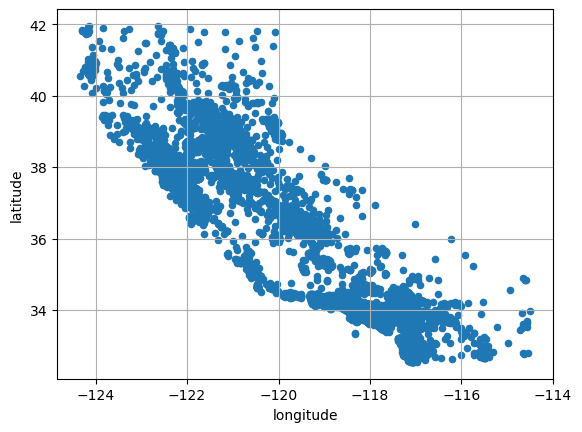

In [25]:
#make a copy of original training set
housing = strat_train_set.copy()    
housing.plot(kind='scatter', x='longitude', y = 'latitude', grid=True)

<Axes: xlabel='longitude', ylabel='latitude'>

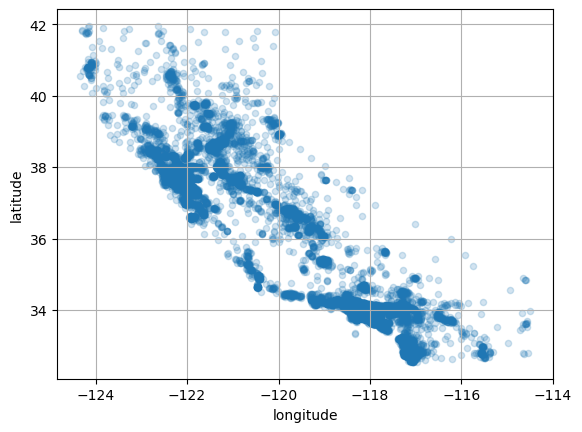

In [26]:
#check densed areas
housing.plot(kind='scatter', x='longitude', y = 'latitude', grid=True, alpha=0.2)

<Axes: xlabel='longitude', ylabel='latitude'>

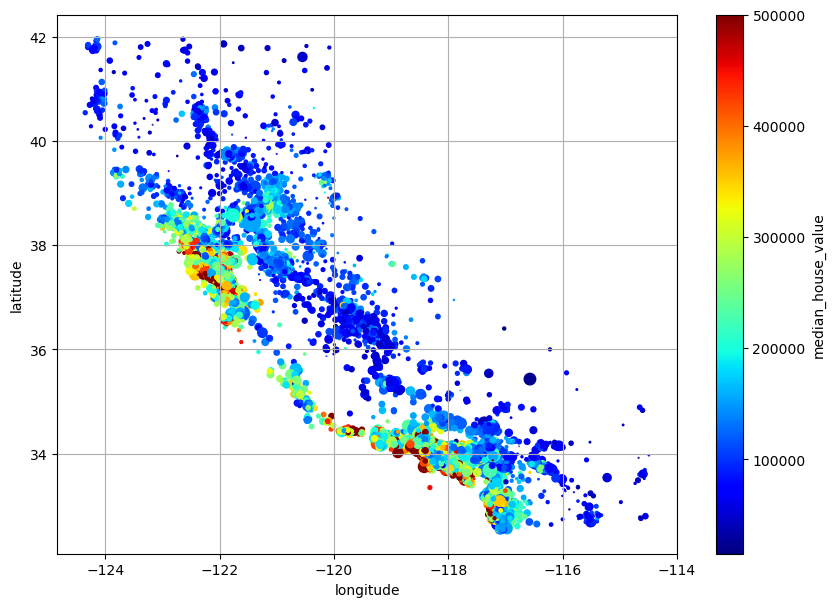

In [27]:
housing.plot(kind='scatter', x='longitude', y = 'latitude', grid=True, s=housing['population']/100, c='median_house_value', cmap='jet', colorbar=True, legend=True, sharex=False, figsize=(10,7))

In [28]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000


In [29]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

<Axes: >

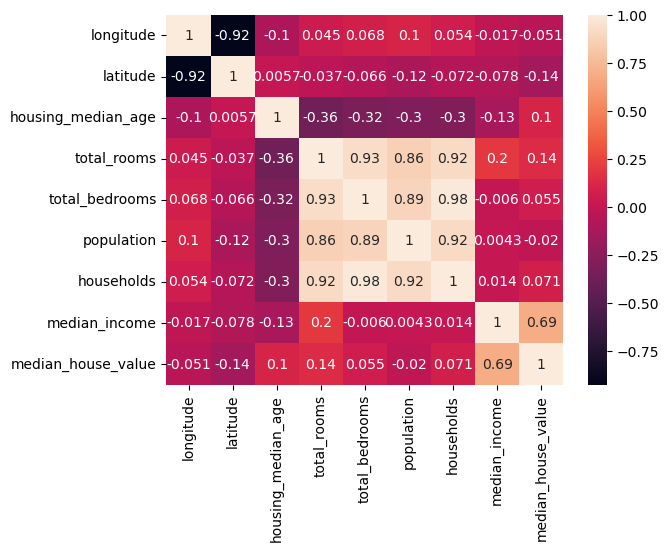

In [30]:
import seaborn as sns

sns.heatmap(
    corr_matrix,
    annot=True #show correlation number
)

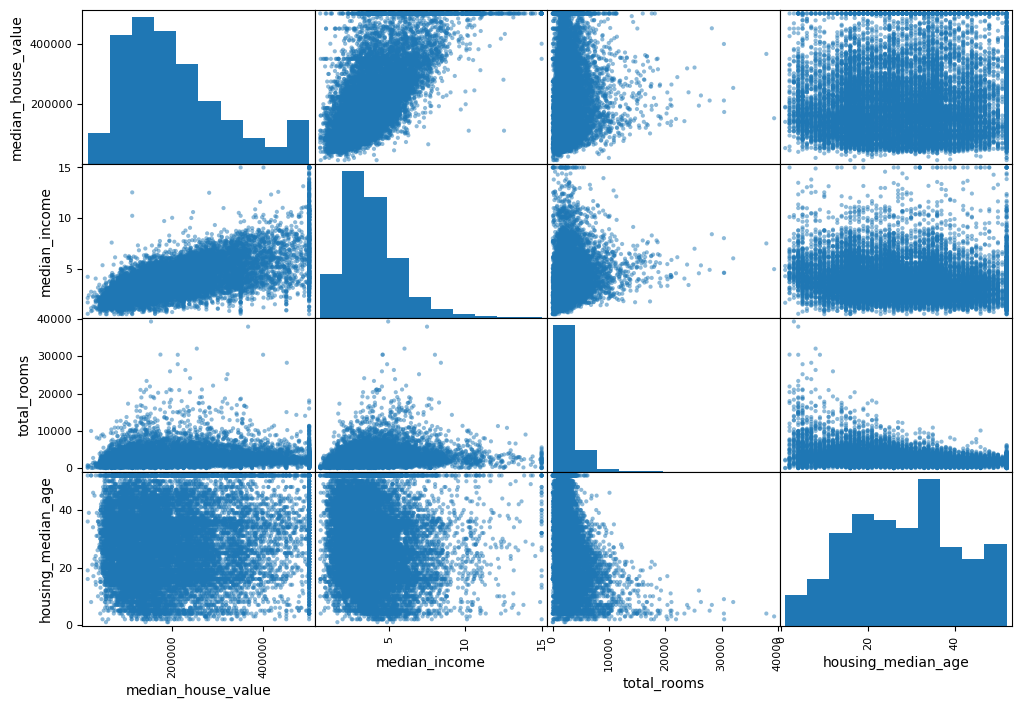

In [31]:
from pandas.plotting import scatter_matrix

scatter_matrix(housing[['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']], figsize=(12, 8)) #The main diagonal would be full of straight lines if Pandas plotted each variable against itself, which would not be very useful. So instead, the Pandas displays a histogram of each attribute (other options are available too)
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

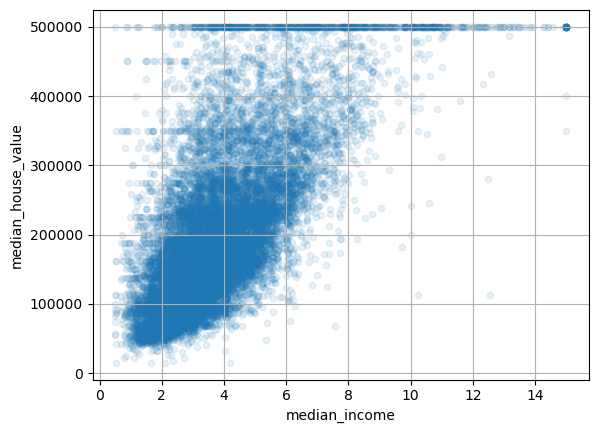

In [32]:
housing.plot(kind='scatter', x='median_income', y = 'median_house_value', alpha=0.1, grid=True) #most correlated attributes

`total_rooms`, `total_bedrooms`, `population` is not that useful to know for a district, instead  
`total_rooms_per_household`, `total_bedrooms_per_room`, `total_population_per_household` are the insights that might be useful

In [33]:
housing['total_rooms_per_household'] = housing['total_rooms']/housing['households']
housing['total_bedrooms_per_room'] = housing['total_bedrooms']/housing['total_rooms']
housing['total_population_per_household'] = housing['population']/housing['households']

housing[['total_rooms_per_household', 'total_bedrooms_per_room', 'total_population_per_household']]


,total_rooms_per_household,total_bedrooms_per_room,total_population_per_household
13096,3.211799,0.335742,1.524178
14973,5.504202,0.180153,1.865546
3785,5.334975,0.200369,2.768473
14689,5.351282,0.203881,2.365385
20507,3.725256,0.277371,1.631399
...,...,...,...
14207,4.277247,0.266875,1.793499
13105,5.535714,0.201019,2.667293
19301,5.157895,0.197704,3.702632
19121,4.511933,0.230891,2.058473


In [34]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

#indeed, `total_rooms_per_household` is more positively correlated, and `total_bedrooms_per_room` is more negatively correlated with `median_house_value`

median_house_value                1.000000
median_income                     0.688380
total_rooms_per_household         0.143663
total_rooms                       0.137455
housing_median_age                0.102175
households                        0.071426
total_bedrooms                    0.054635
population                       -0.020153
total_population_per_household   -0.038224
longitude                        -0.050859
latitude                         -0.139584
total_bedrooms_per_room          -0.256397
Name: median_house_value, dtype: float64

In [35]:
housing = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()
# print(housing_labels)
print(housing)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   
...          ...       ...                 ...          ...             ...   
14207    -118.40     33.86                41.0       2237.0           597.0   
13105    -119.31     36.32                23.0       2945.0           592.0   
19301    -117.06     32.59                13.0       3920.0           775.0   
19121    -118.40     34.06                37.0       3781.0           873.0   
19888    -122.41     37.66                44.0        431.0           195.0   

       population  households  median_income ocean_

### Cleaning the data

In [36]:
# option 1 (remove the rows with missing values)
# housing.dropna(subset=['total_bedrooms'], inplace=True)

# option 2 (remove the whole attribute)
# housing.drop('total_bedrooms', axis=1, inplace = True)

# option 3 (impute missing values)
# median = housing['total_bedrooms'].median()
# housing['total_bedrooms'] = housing['total_bedrooms'].fillna(median)
# print(housing['total_bedrooms'].isnull().sum())


<u>Option 1 (remove the rows with missing values)</u>
```py
housing.dropna(subset=['total_bedrooms'], inplace=True)
```

<u>Option 2 (remove the whole attribute)</u>
```py
housing.drop('total_bedrooms', axis=1, inplace = True)
```
<u>Option 3 (impute missing values)</u>
```py
median = housing['total_bedrooms'].median()
housing['total_bedrooms'] = housing['total_bedrooms'].fillna(median)
print(housing['total_bedrooms'].isnull().sum())
```

In [37]:
#using sklearn's SimpleImputer

from sklearn.impute import SimpleImputer
from sklearn import set_config

#imputer.transform() can still output a numpy array of SciPy sparse matrix even if the input data is Pandas
# set_config(transform_output="pandas") #forces the output to be pandas only, pandas in pandas out

imputer = SimpleImputer(strategy = 'median') #'mean', 'most_frequent', 'constant' is also available
#more powerful imputation transformers are available in the sklearn.impute module, such as KNNImputer ( replaces each missing value with the mean of the k-nearest neighbors’ values for that feature. The distance is based on all the available features.) and IterativeImputer 

housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)
imputer.statistics_, housing_num.median().values

(array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
         408.    ,    3.5385]),
 array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
         408.    ,    3.5385]))

In [38]:
X = imputer.transform(housing_num)
X #return a numpy array or SciPy sparse matrix if sklean.set_config(transform_output='pandas') is not set

array([[-1.2242e+02,  3.7800e+01,  5.2000e+01, ...,  1.5760e+03,
         1.0340e+03,  2.0987e+00],
       [-1.1838e+02,  3.4140e+01,  4.0000e+01, ...,  6.6600e+02,
         3.5700e+02,  6.0876e+00],
       [-1.2198e+02,  3.8360e+01,  3.3000e+01, ...,  5.6200e+02,
         2.0300e+02,  2.4330e+00],
       ...,
       [-1.1706e+02,  3.2590e+01,  1.3000e+01, ...,  2.8140e+03,
         7.6000e+02,  4.0616e+00],
       [-1.1840e+02,  3.4060e+01,  3.7000e+01, ...,  1.7250e+03,
         8.3800e+02,  4.1455e+00],
       [-1.2241e+02,  3.7660e+01,  4.4000e+01, ...,  6.8200e+02,
         2.1200e+02,  3.2833e+00]])

In [39]:
# manually converting the numpy array to pandas dataframe, since sklearn.set_config(transform_output='pandas') was not called
housing_num = pd.DataFrame(X, columns=housing_num.columns, index = housing_num.index)
housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292
...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455


In [40]:
housing_ocean = housing[['ocean_proximity']]
housing_ocean.head()

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN


In [41]:
#converting vategory attr ocean_proximity to numeric 
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_ocean_num = ordinal_encoder.fit_transform(housing_ocean)
housing_ocean_num[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [42]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [43]:
from sklearn.preprocessing import OneHotEncoder

ohe_encoder = OneHotEncoder(sparse_output=False) #OneHotEncoder(sparse_output=False) to get the numpy array as output instead of sparse matrix
housing_ocean_ohe = ohe_encoder.fit_transform(housing_ocean)
# housing_ocean_ohe.toarray()
housing_ocean_ohe

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [44]:
ohe_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [45]:
ohe_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [46]:
ohe_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [47]:
#pandas method get_dummies() to do the onehotencoding
pd_ohe = pd.get_dummies(housing_ocean)

Disadvantages of `get_dummies()`
  - if train set is ["NEAR BAY", "INLAND", "ISLAND"] and test set is ["NEAR BAY", "INLAND"], the "ISLAND" column will be disappeared in the test set, `OneHotEncoder()` handles this case because it learns the categories and for missing columns it will put all 0s 
  - if new cateogry appears, `get_dummies()` will break, but `OneHotEncoder()` will handle it by putting all 0s for the new category
  - also `OneHotEncoder()` is useful in creating pipelines

In [48]:
###### DANGEROUS CASE- columns mismatch
train = pd.DataFrame({"ocean": ["INLAND", "NEAR BAY", "ISLAND"]})
test1  = pd.DataFrame({"ocean": ["INLAND", "NEAR BAY"]})
test2 = pd.DataFrame({"ocean": ["INLAND", "NEAR BAY", "ISLAND", "NEAR OCEAN"]})

train_enc = pd.get_dummies(train["ocean"])
test1_enc  = pd.get_dummies(test1["ocean"])
test2_enc = pd.get_dummies(test2["ocean"])

print(train_enc)
print(test1_enc)
print(test2_enc)
#NOTICE: `ocean_ISLAND` column is missing in test1_enc, which can cause problems for ML model, as it will expect that column to be there and `NEAR_OCEAN` column is present in test2_enc which can create problem

###### Correct way using `OneHotEncoder()`
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Fit ONLY on train
ohe.fit(train)

# Transform both
train_enc = ohe.transform(train)
test1_enc  = ohe.transform(test1)
test2_enc  = ohe.transform(test2)

# Convert to DataFrame
cols = ohe.get_feature_names_out(["ocean"])

train_df = pd.DataFrame(train_enc, columns=cols)
test1_df  = pd.DataFrame(test1_enc, columns=cols)
test2_df  = pd.DataFrame(test2_enc, columns=cols)

print(train_df)
print(test1_df)
print(test2_df)

#NOTICE: `ocean_ISLAND` column is not missing in test set, as OneHotEncoder() has learned the categories, missing data is filled with 0s and new category from test2 set is put as all 0s

   INLAND  ISLAND  NEAR BAY
0    True   False     False
1   False   False      True
2   False    True     False
   INLAND  NEAR BAY
0    True     False
1   False      True
   INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0    True   False     False       False
1   False   False      True       False
2   False    True     False       False
3   False   False     False        True
   ocean_INLAND  ocean_ISLAND  ocean_NEAR BAY
0           1.0           0.0             0.0
1           0.0           0.0             1.0
2           0.0           1.0             0.0
   ocean_INLAND  ocean_ISLAND  ocean_NEAR BAY
0           1.0           0.0             0.0
1           0.0           0.0             1.0
   ocean_INLAND  ocean_ISLAND  ocean_NEAR BAY
0           1.0           0.0             0.0
1           0.0           0.0             1.0
2           0.0           1.0             0.0
3           0.0           0.0             0.0


## Feature Scaling
##### Normalizing the data: using sklearn `MinMaxScaler`(Normalization) and `StandardScaler`(Standardization)

In [49]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)
housing_num_min_max_scaled

array([[-0.60851927,  0.11702128,  1.        , ..., -0.80701754,
        -0.61433638, -0.7794789 ],
       [ 0.21095335, -0.66170213,  0.52941176, ..., -0.91866029,
        -0.86708979, -0.22929339],
       [-0.51926978,  0.23617021,  0.25490196, ..., -0.93141946,
        -0.92458466, -0.73336919],
       ...,
       [ 0.47870183, -0.99148936, -0.52941176, ..., -0.65513434,
        -0.71663244, -0.50873781],
       [ 0.20689655, -0.6787234 ,  0.41176471, ..., -0.78873758,
        -0.68751167, -0.49716556],
       [-0.60649087,  0.08723404,  0.68627451, ..., -0.91669734,
        -0.92122457, -0.61608805]])

`Standardization`: first it subtracts the mean value (so standardized values have a zero mean), then it divides the result by the standard deviation (so standardized values have a standard deviation equal to 1). Unlike min-max scaling, standardization does not restrict values to a specific range. However, standardization is much less affected by outliers.

In [50]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler() #Z = (X-mean)/S.D
std_scaler_without_mean = StandardScaler(with_mean=False) #Z = (X/S.D), use this when you have sparse matrix, as centering the data would make it non-sparse and would consume a lot of memory
housing_num_std_scaler = std_scaler.fit_transform(housing_num)
housing_num_std_scaler

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]])

When a feature's distribution has a heavy tail (i.e values far from the mean are not exponentially rare). First fix the distribution to  make distribution roughly symmetrical (since ML models dont work well with skewed data) before scaling/mormalizing

Text(0, 0.5, 'Number of districts')

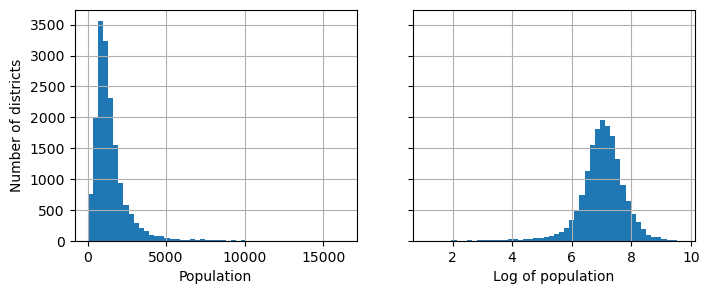

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing['population'].hist(ax=axs[0], bins=50, grid = True)
housing['population'].apply(np.log).hist(ax=axs[1], bins=50, grid=True)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

#### Other approaches to handle skewed data or outliers or heavy-tailed features-
 - `Bucketizing` the feature: chopping the distribution into roughly equally sized buckets, bucketizing with equal sized buckets results in a feature with almost uniform distribution, which is good for ML models, so no need of further scaling and we can just divide each bucket proportion by the total no. of buckets to force the values in 0-1 range 
 - `Multimodal data + OneHotEncoding`: if we treat age as numbers in `housing_median_age` then 50>20, we dont want out model to learn that, because house aged 50 might priced equally as house aged 20
    - Step 1: Bucketize the features lets say in 5 buckets 
    - Step 2: `OneHotEncode()` the bucketized feature
 - `RBF (Radial Basis Function)` (most important): measures how close a value is to something important, bucketizing gives sudden jump eg. age 32 -> bucket 1 and age 33 -> bucket 2, but RBF will give a smooth curve, so age 32 and 33 will have different but similar values as they are nearby.
   - formula: $RBF(x) = exp(-\gamma * (x - center)^2)$ 

In [52]:
from sklearn.metrics.pairwise import rbf_kernel

ages = np.array([[32,33], [33,34], [34,35], [35,34], [36,34], [37,35], [38,37], [39,38], [40,33]])
print(ages.shape)
rbf_trial = rbf_kernel(ages, [[35, 34], [40,33]], gamma = 0.1)
rbf_trial #each row represents how close the ages are from [35,34] and [40,33] resp

# rage_simil_35 = rbf_kernel(housing_num[['housing_median_age']], [[35]], gamma = 0.1)
# age_simil_35

(9, 2)


array([[0.36787944, 0.00166156],
       [0.67032005, 0.00673795],
       [0.81873075, 0.01831564],
       [1.        , 0.07427358],
       [0.90483742, 0.18268352],
       [0.60653066, 0.27253179],
       [0.16529889, 0.13533528],
       [0.0407622 , 0.07427358],
       [0.07427358, 1.        ]])

Gaussian RBF feature measuring the similarity between housing median age and age 35

Text(0, 0.5, 'Age Similarity')

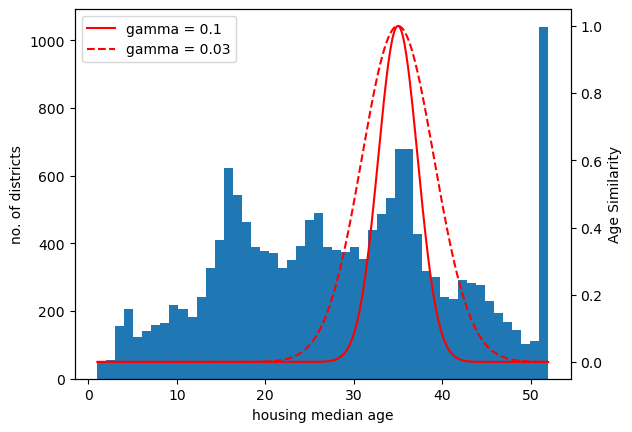

In [53]:
fig, ax1 = plt.subplots()
ax1.set_xlabel('housing median age')
ax1.set_ylabel('no. of districts')
ax1.hist(housing_num['housing_median_age'], bins=50) #or housing_num[['housing_median_age']].hist(ax=ax1, bins=50)

ages = np.linspace(housing_num['housing_median_age'].min(), housing_num['housing_median_age'].max(), 500).reshape(-1,1) #-1 (to figure out no. of rows automatically, here 500) and 1 (explicitly mentioned as 1), so array shape would be (500,1)
rbf1 = rbf_kernel(ages, [[35]], gamma=0.1) # more steep
rbf2 = rbf_kernel(ages, [[35]], gamma=0.03)# less steep

ax2 = ax1.twinx()
ax2.plot(ages, rbf1, color='red', label='gamma = 0.1')
ax2.plot(ages, rbf2, color='red', label='gamma = 0.03', linestyle='--')
plt.legend(loc='upper left')
ax2.set_ylabel("Age Similarity")

In [54]:
from sklearn.linear_model import LinearRegression

std_scaler = StandardScaler()
scaled_labels = std_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[['median_income']], scaled_labels)

some_test_data = housing[['median_income']].iloc[:5]
scaled_predictions = model.predict(some_test_data)
predictions = std_scaler.inverse_transform(scaled_predictions)
predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

In [55]:
#TransformedTargetRegressor() does the same as above but, scales the data while fitting (eg. `housing_labels` in our case) and inverse_transform() both behind the scenes
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),transformer=StandardScaler())
model.fit(housing[['median_income']], housing_labels)
predictions = model.predict(some_test_data)
predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

In [56]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log,np.exp)#(function,inverse_function)
log_pop = log_transformer.transform(housing_num[['population']])
log_pop

,population
13096,7.362645
14973,6.501290
3785,6.331502
14689,7.520235
20507,7.555905
...,...
14207,6.843750
13105,7.257708
19301,7.942362
19121,7.452982


In [57]:
rbf_transformer = FunctionTransformer(rbf_kernel,kw_args=dict(Y=[[35]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing_num[['housing_median_age']])
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]])

In [58]:
# rbf_kernel() does not treat feature seperately, If you pass it an array with two features, it will measure the 2D distance (Euclidean) to measure similarity. 

sf_coords = 37.7749, -122.41 #sanfrancisco (sf) coordinates
sf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[sf_coords], gamma=0.1)) #measures the geographic similarity between each district and sanfrancisco(sf)
sf_simil = sf_transformer.transform(housing[['latitude', 'longitude']])
sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]])

**Custom Transformers**

In [59]:
a = np.array([[1,2],[3,4]])
# a[:,[0]], a[:, [1]]
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(a)

array([[0.5 ],
       [0.75]])

`FunctionTransformer()` is very handy but If we want our tranformer to be trainable (i.e, learn parameters using `fit()` and then predict using `transform()`), we would need to write custom class

## Custom Class for transformer

Scikit learn relies on Duck Typing, so custom transformer class donot have to inherit from particular base class, all they need is `fit()` (which must return self), `transform()` and `fit_transform()`

- using `TransformerMixin` as base class: for  `fit()` and then `transform()` methods
- using `BaseEstimator` as base class: to get 2 extra methods- `get_params()` and `set_params()` (useful for hyperparameter tuning)

In [60]:
#custom transformer that acts much like the StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted #validation package is used extensively in production, here we used a sample

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):
        self.with_mean = with_mean

    def fit(self, X, y=None): #not using y here, sklearn piplelines require X and y as args
        X = check_array(X)
        self.mean_ = X.mean(axis=0) #axis=0 is along the rows(vertically), axis=1 is along the columns(horizontally)
        self.sd_ = X.std(axis=0)
        self.n_feature_in_ = X.shape[1] #All Scikit-Learn estimators set n_features_in_ in the fit() method,
        return self #always returns self

    def transform(self, X):
        #Moreover, all transformers should provide a get_feature_names_out() method, as well as an inverse_transform() method
        check_is_fitted(X) #looks for learned attributes (with trailing '_')
        X = check_array(X)
        assert self.n_feature_in_ == X.shape[1]
        if self.with_mean == True:
            X = X - self.mean_
        return X / self.sd_

In [61]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=0.1, random_state=None):
        self.n_clusters=n_clusters
        self.gamma = gamma
        self.random_state = random_state
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters,random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self
    def transform(self, X):
        return rbf_kernel(X,self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f'Cluster {i} similarity' for i in range(self.n_clusters)]

# You can check whether your custom estimator respects Scikit-Learn’s API by passing an instance to check_estimator() from the sklearn.utils.estimator_checks package

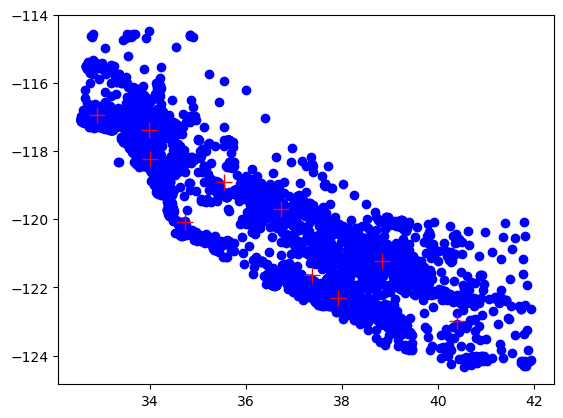

In [62]:
cluster_simil  = ClusterSimilarity(n_clusters=10, gamma=1. , random_state=42)
centers = cluster_simil.fit(housing[['latitude', 'longitude']]).kmeans_.cluster_centers_
centers = pd.DataFrame(centers, columns=list('xy'))
fig, ax = plt.subplots()
ax.plot(housing['latitude'], housing['longitude'], 'bo')
plt.plot(centers['x'], centers['y'], 'r+', markersize=12)

In [63]:
similarities = cluster_simil.fit_transform(housing[['latitude', 'longitude']])
similarities.round(3), similarities.max(axis=1)

(array([[0.458, 0.   , 0.081, ..., 0.977, 0.   , 0.   ],
        [0.   , 0.958, 0.   , ..., 0.   , 0.11 , 0.355],
        [0.343, 0.   , 0.448, ..., 0.73 , 0.   , 0.   ],
        ...,
        [0.   , 0.035, 0.   , ..., 0.   , 0.   , 0.135],
        [0.   , 0.967, 0.   , ..., 0.   , 0.09 , 0.348],
        [0.513, 0.   , 0.061, ..., 0.931, 0.   , 0.   ]]),
 array([0.97703222, 0.95795964, 0.73032649, ..., 0.90328343, 0.96670733,
        0.93072468]))

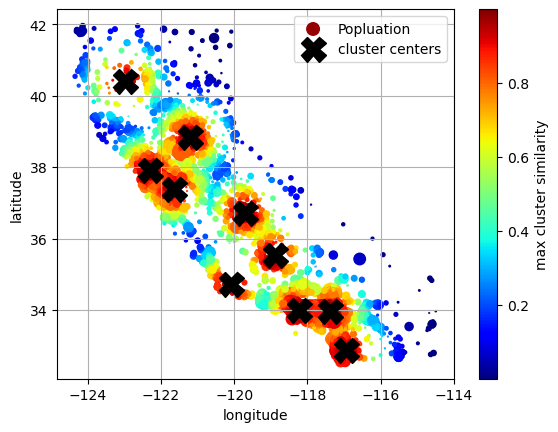

In [64]:
housing['max cluster similarity'] = similarities.max(axis=1)
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True, s=housing['population']/100, c='max cluster similarity', cmap='jet', colorbar= True, label='Popluation') #c and s belongs to **kwargs, pandas.plot is a very high level api, underneath matplotlib.plt.scatter() is being used
# plt.plot(centers['x'], centers['y'], marker='X', linestyle='', markersize=18, color='black', label='cluster centers')
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],cluster_simil.kmeans_.cluster_centers_[:, 0] , marker='X', linestyle='', markersize=18, color='black', label='cluster centers')
plt.legend(loc='upper right')


In [65]:
housing = housing.drop('max cluster similarity', axis=1)

## Transformation Pipelines

- <u>Estimator</u>:    
        - Estimator is any object that learns from data  
        - Estimator is any object that has `fit()` method
     
Estimators are of 2 types-  
1. Transformers
   - Transformer is an estimator that also has `transform()`
   - Transformer is an estimator that modifies data  
   - Methods: `fit()`, `transform()`, `fit_transform()`
2. Predictors (models)  
   - Predictors is an estimator that also has `predict()`
   - eg. 
        ```py   model = LinearRegression()
                model.fit(X, y)
                y_pred = model.predict(X)
        ```

In [66]:
# all the estimators must be transformers, except the last one, which can be anything: a transformer, a predictor, or any other type of estimator. 

# Pipeline([
#     ("impute", SimpleImputer()),     # transformer
#     ("scale", StandardScaler()),     # transformer
#     ("model", LinearRegression())    # predictor
# ])

from sklearn.pipeline import Pipeline, make_pipeline
import sklearn

# sklearn.set_config(display='diagram') #all sklearn estimators will be rendered as interactive diagrams

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='mean')), ('standardize', StandardScaler())
    ])
num_pipeline = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler()) #if we dont want to name the transformers ,we can use `make_pipeline`, If multiple transformers have the same name, an index is appended to their names (e.g., "foo-1", "foo-2", etc.).
num_pipeline

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [67]:
#A pipeline exposes the same methods as the final estimator in the pipeline
#if the last estimator was StandardScaler() which is a transformer, so pipeline also acts as transformer, calling transform() will apply tranformations to all the data sequentially
#if the last estimator was predictor instead, then pipeline would have predict() method rather than transform(), calling it will apply all the tranformations to the data and pass the result to the predictor's predict method at last

housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)
pd.DataFrame(housing_num_prepared, columns=num_pipeline.get_feature_names_out(), index=housing_num.index)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365
...,...,...,...,...,...,...,...,...
14207,0.586397,-0.833359,0.987087,-0.184147,0.140152,-0.445315,0.060101,0.444041
13105,0.131525,0.319822,-0.443146,0.139847,0.128298,-0.005950,0.083608,-0.685630
19301,1.256209,-1.428701,-1.237721,0.586026,0.562134,1.268299,0.679135,0.101049
19121,0.586397,-0.739605,0.669257,0.522417,0.794461,0.273563,0.882868,0.145396


In [68]:
#pipeline supports indexing
num_pipeline[:-1] 

,steps,"[('simpleimputer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [69]:
#seperating transformers for different attribute types
from sklearn.compose import ColumnTransformer

num_attrib = ["longitude", "latitude", "housing_median_age", "total_rooms",
"total_bedrooms", "population", "households", "median_income"]
cat_attrib =  ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown="ignore")
    )

preprocessing = ColumnTransformer([
    ('numerical', num_pipeline, num_attrib),
    ('categorical', cat_pipeline, cat_attrib)
], remainder='passthrough') #remainder='passthrough' keeps the column which were not mentioned as-is (default behaviour is 'drop', i.e columns not mentioned will be dropped)
preprocessing

#can also be written as
# ColumnTransformer([('col_num', 'drop', ['id']), ('keep_col','passthrough', 'age')]) #tranformer replaced with 'drop' to remove the column 'id', and 'passthrough' to keep the column 'age' intact


,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [70]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object))
)
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.        ,
         0.        ,  0.        ],
       [-1.2030985 ,  1.27611874,  0.35142777, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41803793,  0.94797769,  1.22545939, ...,  0.        ,
         0.        ,  1.        ]])

In [71]:
pd.DataFrame(housing_prepared, columns=preprocessing.get_feature_names_out(), index=housing.index)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.366061,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.438593,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0
3785,-1.203098,1.276119,0.351428,-0.712240,-0.763478,-0.788768,-0.775727,-0.759789,0.0,1.0,0.0,0.0,0.0
14689,1.231216,-0.884924,-0.919891,0.702262,0.740005,0.383175,0.731375,-0.850281,0.0,1.0,0.0,0.0,0.0
20507,0.711362,-0.875549,0.589800,0.790125,1.593718,0.444376,1.755263,-0.180365,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14207,0.586397,-0.833359,0.987087,-0.184147,0.137663,-0.445315,0.060101,0.444041,1.0,0.0,0.0,0.0,0.0
13105,0.131525,0.319822,-0.443146,0.139847,0.125806,-0.005950,0.083608,-0.685630,0.0,1.0,0.0,0.0,0.0
19301,1.256209,-1.428701,-1.237721,0.586026,0.559777,1.268299,0.679135,0.101049,0.0,0.0,0.0,0.0,1.0
19121,0.586397,-0.739605,0.669257,0.522417,0.792177,0.273563,0.882868,0.145396,1.0,0.0,0.0,0.0,0.0


In [72]:
def column_ratio(X):
    return X[:,[0]]/X[:,[1]]
def ratio_name(fuction_transformer, feature_names_in):
    # return [f'{feature_names_in[0]}_per_{feature_names_in[1]}']
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name), #made the anonymous fn lambda X: X[:,[0]]/ X[:,[1]] to column_ratio, to pickle the variables 
        StandardScaler()
    )

log_pipeline = make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(np.log, feature_names_out='one-to-one'), #one-to-one keep the original feature name
        StandardScaler()
    )


cluster_simil  = ClusterSimilarity(n_clusters=10, gamma=1. , random_state=42)

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),StandardScaler())

preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)

In [73]:

housing_prepared = preprocessing.fit_transform(housing)
# housing_prepared.shape, preprocessing.get_feature_names_out()
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,<1H OCEAN
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,INLAND
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,NEAR OCEAN
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,<1H OCEAN


### Train and evaluate on training set

In [74]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

#we now have a working linear regression model

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:3].round(-2) #-2 = round to the nearest hundred

array([246000., 372700., 135700.])

In [76]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [77]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse #high(underfit, model is not powerful enough)

68972.88910758485

##### Lets try `DecisionTreeRegressor` capable of finding complex non-linear relationshiop in the data

In [78]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
housing_prediction = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_prediction)
tree_rmse #0 = possibly overfit

0.0

In [80]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg,housing, housing_labels,scoring="neg_root_mean_squared_error", cv=10)
tree_rmses

array([64607.89604624, 66409.0627187 , 66203.41031283, 65863.76434319,
       68086.79141027, 66534.53308312, 66923.49892937, 68532.21066423,
       66367.48227837, 66208.69621463])

In [81]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66573.734600
std       1103.402323
min      64607.896046
25%      66204.731788
50%      66388.272499
75%      66826.257468
max      68532.210664
dtype: float64

In [82]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
# forest_rmses = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10)
# forest_rmses #array([46424.2624356 , 46582.62311709, 44909.19374696, 46131.52214054, 45454.60433668, 47210.95251833, 46863.22566346, 48743.6685734, 46621.39780472, 46382.75147018])

#took 12 minutes to calculate

In [83]:
forest_rmses = [46424.2624356 , 46582.62311709, 44909.19374696, 46131.52214054,
       45454.60433668, 47210.95251833, 46863.22566346, 48743.6685734 ,
       46621.39780472, 46382.75147018]
pd.Series(forest_rmses).describe()

count       10.000000
mean     46532.420181
std       1025.305608
min      44909.193747
25%      46194.329473
50%      46503.442776
75%      46802.768699
max      48743.668573
dtype: float64

## Fine tuning the model
- using Grid Search- `GridSearchCV()`
- `RandomizedSearchCV()`
- Ensemble methods
  

In [84]:
###warning: it will take minutes to execute

# from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

# param_grid = [
#     {   
#         #total cases: (5,4),(5,6), (5,8), (8,4),(8,6),(8,8), (10,4), (10,6), (10,8) = 9 cases
#         'preprocessing__geo__n_clusters':[5,8,10], #nested pipeline: go to 'geo' pipeline inside the 'preprocessing' pipeline and tweak the n_clusters parameter
#         'random_forest__max_features': [4,6,8]
#     },
#     {
#         'preprocessing__geo__n_clusters':[10,15], 
#         'random_forest__max_features': [6,8,10]
#     }
# ]

#GridSearchCV is a cross validation method only but with ability to fine tune
# grid_search = GridSearchCV(full_pipeline, param_grid=param_grid, cv=3, scoring='neg_root_mean_squared_error')
# grid_search.fit(housing, housing_labels)

# %store grid_search # since i used the lambda fuction somewhere in the preprocessing pipeline like FunctionTransformer(lambda X: X[:,[0]]/X[:,[1]], feature_names_out=ratio_name), i was getting the error as "Can't pickle <function <lambda> at 0x7f1099cbb100>"
#pickle cannot reconstruct the anonymous functions as they are unnamed


In [85]:
# %store -r grid_search
# grid_search.best_params_  #{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}, trend looks like increasing preprocessing__get__n_cluster may increase the score, check with values >15

We can access the best estimator using `grid_search.best_estimator_`, out of all the trained models, best model with lowest RMSE is choosed and if `reflit=True`(default behaviour) in `GridSearchCV(..., reflit=True)` then that model is retrained on the whole dataset (since, k-folds CV only exposes a small portion of data to get trained on)

In [86]:
# cv_res = pd.DataFrame(grid_search.cv_results_)
# cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
# cv_res.head()

#### Randomized Search
used especially when the hyperparameter search space is large

instead of trying out all possible combinations `RandomizedSearchCV()` evaluates a fixed number of combinations, selecting a random value for each hyperparameter at every iteration.

for hyperparameters, either a list of possible values or probability distribution can be given

In [87]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),
    'random_forest__max_features': randint(low=2, high=20)
    }

rnd_search = RandomizedSearchCV(full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
scoring='neg_root_mean_squared_error', random_state=42)
rnd_search = rnd_search.fit(housing, housing_labels)

In [88]:
%store rnd_search

Stored 'rnd_search' (RandomizedSearchCV)


In [89]:
%store -r rnd_search
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}

In [90]:
rnd_search_cv_res = pd.DataFrame(rnd_search.cv_results_)
rnd_search_cv_res = rnd_search_cv_res.sort_values(by='rank_test_score')
rnd_search_cv_res = rnd_search_cv_res[['rank_test_score','param_preprocessing__geo__n_clusters', 'param_random_forest__max_features', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score']]

score_cols = ['split0','split1', 'split2', 'mean_test_score']
rnd_search_cv_res.columns = ['rank', 'n_clusters', 'max_features'] + score_cols 
rnd_search_cv_res[score_cols] = -rnd_search_cv_res[score_cols].round().astype(np.int64)
rnd_search_cv_res

,rank,n_clusters,max_features,split0,split1,split2,mean_test_score
1,1,45,9,41342,42242,43057,42214
8,2,32,7,41825,42275,43241,42447
0,3,41,16,42238,42938,43354,42843
5,4,42,4,41869,43362,43664,42965
2,5,23,8,42490,42928,43718,43046
6,6,24,3,42502,43694,44234,43477
7,7,26,13,42827,43506,44245,43526
4,8,13,5,43225,43589,44620,43811
3,9,21,12,43481,43828,44501,43936
9,10,4,2,48955,48833,49929,49239


Scikit-Learn also has `HalvingRandomSearchCV` and `HalvingGridSearchCV` hyperparameter search classes, this does the work most efficiently computationaly.

In first round of either random or grid search, many hyperparameters combinations called 'candidates' are generated, these candidates are then used to train models which then are evaluated using cross-validation as usual. BUT training actually uses limited resources.

By default, 'limited resources' = models are trained on small part of the training set
other limitations possible = reducing the no. of training iterations if the model has a hyperparam to set it

Once every candidate has been evaluated, only the best ones go to the second round. After several rounds, the final candidates are evaluated using full resources. This will save some time tuning
hyperparameters.

#### Ensemble methods
later in chapter 6

### Analyzing the best model and their errors

In [91]:
final_model = rnd_search.best_estimator_ #includes preprocessing
feature_importances = final_model['random_forest'].feature_importances_
feature_importances.round(2)

array([0.07, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.02, 0.01,
       0.01, 0.01, 0.  , 0.01, 0.02, 0.01, 0.02, 0.01, 0.  , 0.01, 0.02,
       0.01, 0.01, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.03, 0.01, 0.01, 0.01, 0.01, 0.04, 0.01, 0.02, 0.01, 0.02, 0.01,
       0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.07,
       0.  , 0.  , 0.  , 0.01])

In [92]:
sorted(zip(feature_importances.round(4), final_model['preprocessing'].get_feature_names_out()), reverse=True)

[(0.186, 'log__median_income'),
 (0.0734, 'cat__ocean_proximity_INLAND'),
 (0.0656, 'bedrooms__ratio'),
 (0.0536, 'rooms_per_house__ratio'),
 (0.046, 'people_per_house__ratio'),
 (0.0418, 'geo__Cluster 30 similarity'),
 (0.026, 'geo__Cluster 25 similarity'),
 (0.0236, 'geo__Cluster 36 similarity'),
 (0.0202, 'geo__Cluster 9 similarity'),
 (0.0186, 'geo__Cluster 34 similarity'),
 (0.0181, 'geo__Cluster 37 similarity'),
 (0.0174, 'geo__Cluster 18 similarity'),
 (0.0168, 'geo__Cluster 1 similarity'),
 (0.0155, 'geo__Cluster 7 similarity'),
 (0.0153, 'geo__Cluster 32 similarity'),
 (0.0151, 'geo__Cluster 13 similarity'),
 (0.0143, 'geo__Cluster 35 similarity'),
 (0.0142, 'geo__Cluster 0 similarity'),
 (0.0137, 'geo__Cluster 3 similarity'),
 (0.0136, 'geo__Cluster 28 similarity'),
 (0.0129, 'geo__Cluster 26 similarity'),
 (0.0127, 'geo__Cluster 31 similarity'),
 (0.0117, 'geo__Cluster 19 similarity'),
 (0.0116, 'geo__Cluster 6 similarity'),
 (0.0111, 'geo__Cluster 24 similarity'),
 (0.011, 

we can try dropping the lest important features, eg. categories of `ocean_proximity` like  NEAR BAY and ISLAND is not useful but INLAND is the most useful

**Model fairness** : we are just checking RMSE which is just the average, we should also know how well the model perform on lets say Urban vs Rural Districts  

if, for Urban areas RMSE = 30k  
and for Rural areas RMSE = 80k 

then its a BAD model  

#### Bias Analysis 
Split the validation set into meaningful groups and evaluate each seperately  
Examples in housing dataset:  

- ocean_proximity → NEAR OCEAN, INLAND, etc.  
- income levels → low / medium / high  
- location → north / south  
- population density → urban / rural  

#### Evaluate the system on the test set

In [93]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set['median_house_value'].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
final_rmse

41445.533268606625

In [94]:
# https://www.youtube.com/watch?v=Xz0x-8-cgaQ (BOOTSTRAPING)
from scipy.stats import bootstrap

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

squared_errors = (final_predictions - y_test)**2

boot_result = bootstrap([squared_errors], rmse, confidence_level=0.95, random_state=42)

In [95]:
boot_result.confidence_interval

ConfidenceInterval(low=39520.95719181788, high=43701.76812180527)

#### Production

In [96]:
import joblib

joblib.dump(final_model, 'my_california_housing_model.pkl')

['my_california_housing_model.pkl']

In [97]:
final_model_reloaded = joblib.load('my_california_housing_model.pkl')

new_data = housing.iloc[:5]
final_model_reloaded.predict(new_data)

array([441046.12, 454713.09, 104832.  , 101316.  , 336181.05])